In [1]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load dataset
df = pd.read_csv("employ_promotion.csv")

In [3]:
# dataset overview
df.head()
df.describe()

,Age,Salary,Experience,HoursWorked,Projects,Performance,Promoted
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,30.50000,60650.000000,4.750000,7.850000,4.650000,0.600000,0.600000
std,5.91608,21411.445537,3.041381,1.424411,2.109502,0.502625,0.502625
min,21.00000,28000.000000,0.000000,5.000000,1.000000,0.000000,0.000000
25%,25.75000,41500.000000,2.000000,7.000000,3.000000,0.000000,0.000000
50%,30.50000,64000.000000,5.000000,8.000000,5.000000,1.000000,1.000000
75%,35.25000,80250.000000,7.000000,9.000000,6.000000,1.000000,1.000000
max,40.00000,90000.000000,10.000000,10.000000,8.000000,1.000000,1.000000


In [5]:
# check null values
df.isnull().sum()
(df.isnull().sum()/df.shape[0])*100
df.isnull().sum().sum()
(df.isnull().sum().sum()/df.shape[0]*df.shape[1])*100

0.0

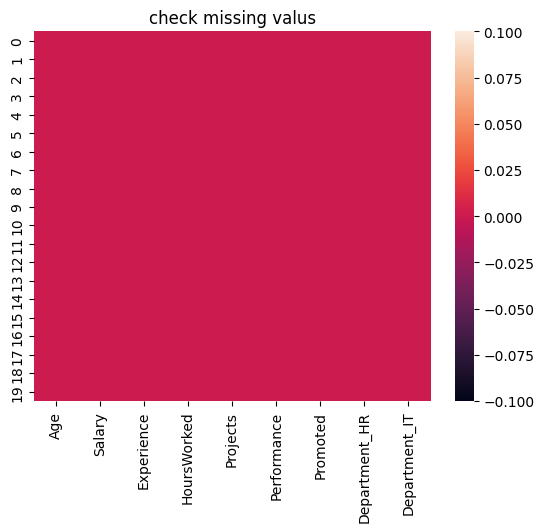

In [72]:
# EDA 
sns.heatmap(df.isnull())
plt.title("check missing valus")
plt.show()

In [11]:
# handling missing values
df.fillna(df.median(numeric_only=True), inplace=True)

x = df.drop(["Promoted", "Performance"], axis=1)
y = df["Promoted"]

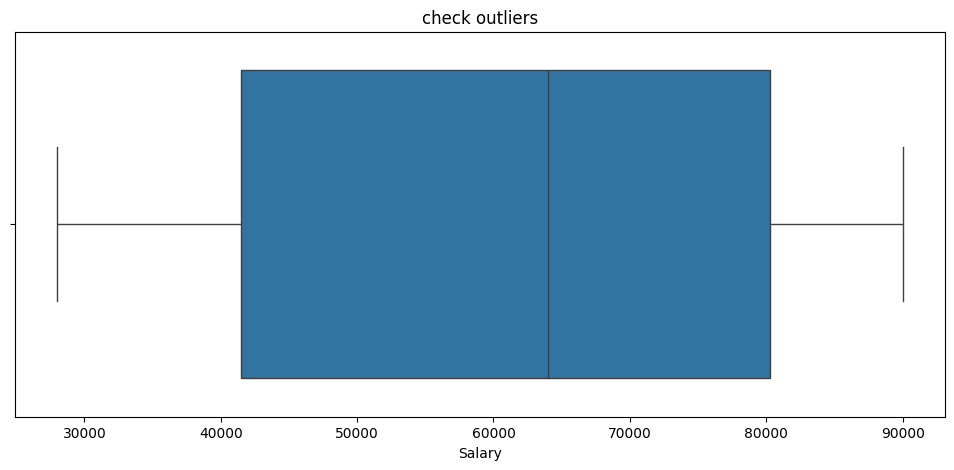

In [12]:
# check outliers
plt.figure(figsize=(12, 5))
sns.boxplot(x="Salary", data=df)
plt.title("check outliers")
plt.show()

In [15]:
# outliers detection
q1 = df["Salary"].quantile(0.25)
q3 = df["Salary"].quantile(0.75)

iqr = q3 - q1 

min_range = q1 - (1.5*iqr)
max_range = q3 + (1.5*iqr)

# remove outlier
df = df[(df["Salary"] >= min_range) & (df["Salary"] <= max_range)]

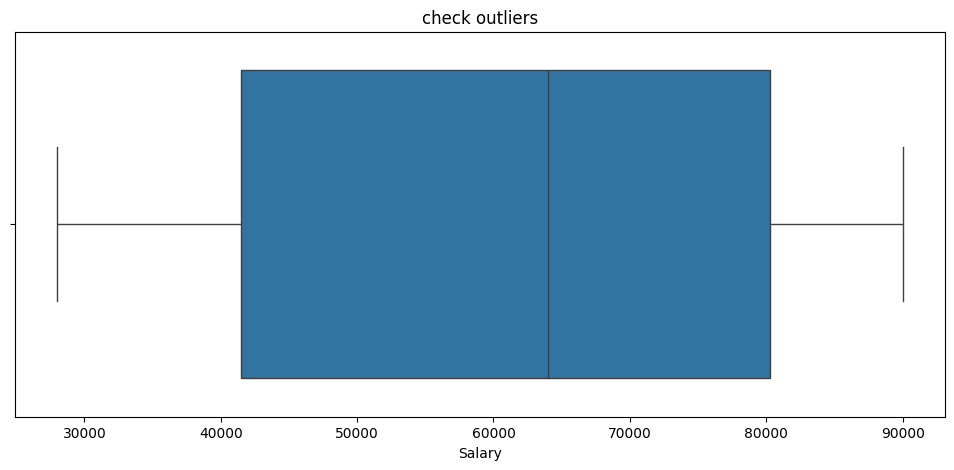

In [21]:
plt.figure(figsize=(12, 5))
sns.boxplot(x="Salary", data=df)
plt.title("check outliers")
plt.show()

In [16]:
# handle duplicates values

df.duplicated().sum()
df.drop_duplicates(inplace=True)

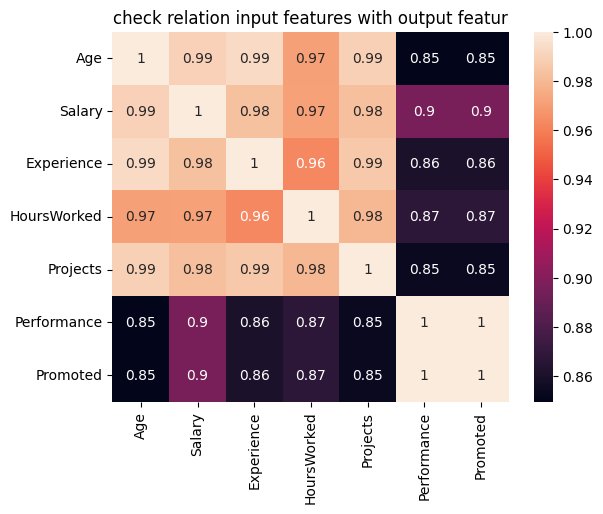

In [17]:
# correlationco

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True)
plt.title("check relation input features with output featur")
plt.show()

In [18]:
# Encoding
df = pd.get_dummies(df, drop_first=True)

In [19]:
# preprocessing
x = df.drop("Promoted", axis=1)
y = df["Promoted"]

In [20]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit only training data
x_train = scaler.fit_transform(x_train)

# transform test data
x_test = scaler.transform(x_test)

In [22]:
# model train
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
# reduce overfitting
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
max_depth = 3,
n_estimators = 50,
random_state = 42

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
# fit model
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
# check overfitting
print("Train Score:", model.score(x_train, y_train))
print("Test Score:", model.score(x_test, y_test))

Train Score: 1.0
Test Score: 1.0


In [39]:
# cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x, y, cv=5)
print("CV Score:", scores.mean())

CV Score: 0.95


In [40]:
# prediction

y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Test Score:", model.score(x_test, y_test))

Accuracy: 1.0
Test Score: 1.0


In [41]:
# feature importance (kon sa feature promotion decide kar rha hai)

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})
featre_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)

         Feature  Importance
0            Age    0.187765
1         Salary    0.190000
2     Experience    0.341407
3    HoursWorked    0.137407
4       Projects    0.120955
5  Department_HR    0.015898
6  Department_IT    0.006567
